# Auditing sensor data with `tsauditor`: catching a stuck sensor and an outage gap

`tsauditor` scans a time-series `DataFrame` and reports data-quality problems
*before* they reach a model. Its README is built around a **finance** example
(the OGDC `ChangeP` leakage case). This notebook is the companion **sensor**
example requested in
[issue #13](https://github.com/imann128/tsauditor/issues/13): a small,
self-contained walkthrough of `tsa.scan(..., domain="sensor")` on synthetic
sensor data.

### Why this use case?

Two failure modes dominate real IoT / industrial sensor streams, and both are
silent — the data still *looks* numeric and complete enough to model on:

1. **A stuck sensor.** A probe freezes and reports the *same value* for hours.
   The reading is plausible, so nothing obvious breaks — but the variance is
   fake. `tsauditor` flags this as **`ANO001` (stuck values)**.
2. **A collection outage.** The logger drops a contiguous block of readings,
   leaving a *clustered* run of missing values (very different from a few
   scattered NaNs). `tsauditor` flags this as **`PRF002` (clustered missing
   values)**.

We build a clean two-channel stream (temperature + humidity), inject one of
each fault, and watch the audit catch exactly those two. Synthetic data keeps
the faults unambiguous, mirroring the `sensor_df` fixture in
`tests/conftest.py`. No real-world data or changes to `tsauditor/` are needed.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tsauditor as tsa

plt.rcParams["figure.figsize"] = (11, 3.2)
plt.rcParams["axes.grid"] = True
print("tsauditor", tsa.__version__)

tsauditor 0.2.0


## 1. A clean synthetic sensor stream

Fourteen days of **hourly** readings (336 rows) for two channels, each with a
daily (24-hour) seasonal cycle plus small measurement noise:

- `temperature` — oscillates around 22 °C
- `humidity` — oscillates around 55 %, phase-shifted from temperature

A fixed seed keeps the notebook reproducible.

In [2]:
def build_sensor_frame(seed: int = 0, inject: bool = True) -> pd.DataFrame:
    """14 days of hourly temperature + humidity with a daily cycle.

    If ``inject`` is True, embed two faults:
      * a 6-hour STUCK period in temperature  -> should trip ANO001
      * a 6-hour MISSING gap in humidity       -> should trip PRF002
    """
    rng = np.random.default_rng(seed)
    n = 24 * 14
    idx = pd.date_range("2024-03-01", periods=n, freq="h", name="timestamp")
    h = np.arange(n)

    temperature = 22 + 3 * np.sin(2 * np.pi * h / 24) + rng.normal(0, 0.25, n)
    humidity = 55 + 8 * np.sin(2 * np.pi * (h + 6) / 24) + rng.normal(0, 0.70, n)

    df = pd.DataFrame(
        {"temperature": temperature.round(2), "humidity": humidity.round(2)},
        index=idx,
    )

    if inject:
        # (a) Stuck sensor: hold one value for 6 consecutive hours.
        s = 24 * 5 + 3
        df.iloc[s : s + 6, df.columns.get_loc("temperature")] = df["temperature"].iloc[
            s
        ]
        # (b) Outage: 6 consecutive missing humidity readings (rows kept, values NaN).
        g = 24 * 9 + 3
        df.iloc[g : g + 6, df.columns.get_loc("humidity")] = np.nan

    return df


clean = build_sensor_frame(inject=False)
clean.head()

,temperature,humidity
timestamp,,
2024-03-01 00:00:00,22.03,63.22
2024-03-01 01:00:00,22.74,61.98
2024-03-01 02:00:00,23.66,62.76
2024-03-01 03:00:00,24.15,59.46
2024-03-01 04:00:00,24.46,58.27


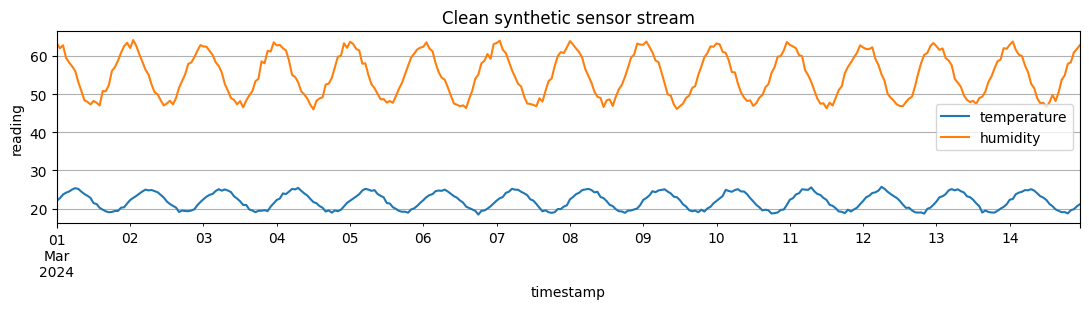

In [3]:
ax = clean.plot(title="Clean synthetic sensor stream")
ax.set_ylabel("reading")
plt.tight_layout()
plt.show()

## 2. Injecting two real-world sensor failures

We now create the *faulted* frame. The thresholds below are the library's
`domain="sensor"` defaults, which is why our injected faults are sized to clear
them:

| Fault | Injected | `domain="sensor"` rule | Expected code |
|-------|----------|------------------------|---------------|
| Stuck sensor | 6 identical values in a row | run length **> 3** (`stuck_window=3`) | `ANO001` |
| Outage gap | 6 consecutive NaNs | run length **≥ 3** (`cluster_threshold=3`) | `PRF002` |

The gap is only ~1.8 % of the column, comfortably under the 30 % rate that
would also raise `PRF006`, so the outage shows up purely as a *clustered* run.

In [4]:
df = build_sensor_frame(inject=True)

stuck_start = 24 * 5 + 3
gap_start = 24 * 9 + 3

print("Stuck temperature segment (note the repeated value):")
print(df["temperature"].iloc[stuck_start - 1 : stuck_start + 7].to_string())
print("\nHumidity outage gap (note the NaNs):")
print(df["humidity"].iloc[gap_start - 1 : gap_start + 7].to_string())
print("\nhumidity missing rate: %.2f%%" % (df["humidity"].isna().mean() * 100))

Stuck temperature segment (note the repeated value):
timestamp
2024-03-06 02:00:00    23.52
2024-03-06 03:00:00    23.76
2024-03-06 04:00:00    23.76
2024-03-06 05:00:00    23.76
2024-03-06 06:00:00    23.76
2024-03-06 07:00:00    23.76
2024-03-06 08:00:00    23.76
2024-03-06 09:00:00    23.86
Freq: h

Humidity outage gap (note the NaNs):
timestamp
2024-03-10 02:00:00    61.05
2024-03-10 03:00:00      NaN
2024-03-10 04:00:00      NaN
2024-03-10 05:00:00      NaN
2024-03-10 06:00:00      NaN
2024-03-10 07:00:00      NaN
2024-03-10 08:00:00      NaN
2024-03-10 09:00:00    49.08
Freq: h

humidity missing rate: 1.79%


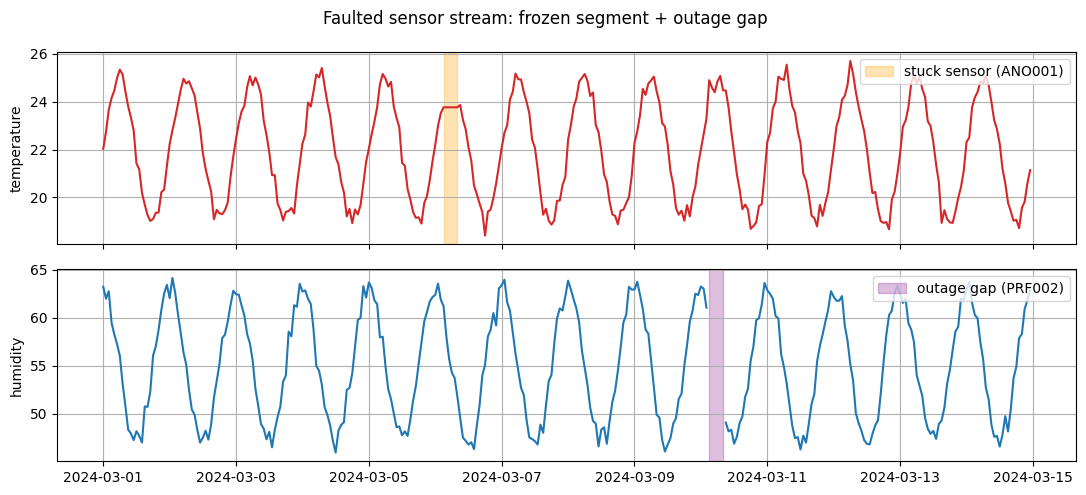

In [5]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

a1.plot(df.index, df["temperature"], color="tab:red")
a1.axvspan(
    df.index[stuck_start],
    df.index[stuck_start + 5],
    color="orange",
    alpha=0.3,
    label="stuck sensor (ANO001)",
)
a1.set_ylabel("temperature")
a1.legend(loc="upper right")

a2.plot(df.index, df["humidity"], color="tab:blue")
a2.axvspan(
    df.index[gap_start],
    df.index[gap_start + 5],
    color="purple",
    alpha=0.25,
    label="outage gap (PRF002)",
)
a2.set_ylabel("humidity")
a2.legend(loc="upper right")

fig.suptitle("Faulted sensor stream: frozen segment + outage gap")
plt.tight_layout()
plt.show()

## 3. Run the audit

One call. `domain="sensor"` selects the sensor threshold presets. We pass no
`target`, so the leakage checks are skipped and the audit focuses on structural
and anomaly quality — the usual situation when validating raw sensor streams.

In [6]:
report = tsa.scan(df, domain="sensor")
report.summary()

──────────────────────────────────────────────── tsauditor Report ─────────────────────────────────────────────────

Dataset

Rows       : 336

Columns    : 2

Time range : 2024-03-01 → 2024-03-14

...

Critical: 0  Warnings: 2  Info: 0

 Severity     Code       Module       Column             Description                                              
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  WARNING      ANO001     anomaly      temperature        Stuck values detected.                                   
  WARNING      PRF002     profiler     humidity           Column 'humidity' contains clustered missing value       
                                                          sequences indicating an outage.

Suggested actions

• ANO001 (temperature): Investigate column 'temperature' for a stuck sensor or a forward-filled gap: the value 
repeats unchanged for an unusually long run.

• PRF002 (humidity): Handle the clustered missing values in column 'humidity' (careful interpolation, limited 
forward-fill, or dropping the affected span) before modeling.

Exactly the two faults we injected, each mapped to the right column:

- **`ANO001` on `temperature`** — the stuck run.
- **`PRF002` on `humidity`** — the clustered outage.

Each line also carries a plain-English suggested action from the report's
advisory layer (`tsauditor` reports and recommends, but never edits your data).

## 4. Inspecting the findings programmatically

`scan()` returns a structured `GuardReport`, not just printed text — so a
pipeline can branch on it (e.g. block training when `report.critical` is
non-empty). Here we read the `evidence` dicts and filter by module.

In [7]:
for issue in report.warnings:
    print(f"[{issue.code}] {issue.column}")
    print("   evidence  :", issue.evidence)
    print("   suggestion:", issue.suggestion)
    print()

print("anomaly-only issues :", [i.code for i in report.filter(module="anomaly")])
print("report counts       :", report.to_dict()["counts"])

[PRF002] humidity
   evidence  : {'missing_percentage': 1.79, 'longest_consecutive_run': 6, 'cluster_count': 1, 'first_occurrence': '2024-03-10 03:00:00', 'cluster_threshold': 3}
   suggestion: Handle the clustered missing values in column 'humidity' (careful interpolation, limited forward-fill, or dropping the affected span) before modeling.

[ANO001] temperature
   evidence  : {'max_stuck_duration': 6}
   suggestion: Investigate column 'temperature' for a stuck sensor or a forward-filled gap: the value repeats unchanged for an unusually long run.

anomaly-only issues : ['ANO001']
report counts       : {'critical': 0, 'warnings': 2}


## 5. Sanity check: a clean stream raises nothing

A good auditor is *specific* — it should stay quiet when the data is fine. Re-running
on the un-faulted frame returns zero issues, confirming the two warnings above
came from our injected faults and not from the seasonal signal or the noise.

In [8]:
clean_report = tsa.scan(clean, domain="sensor")
print(
    "critical:",
    len(clean_report.critical),
    "| warnings:",
    len(clean_report.warnings),
    "| info:",
    len(clean_report.info),
)
assert not clean_report.all_issues, "clean data should produce no issues"
print("Clean stream: no issues detected ✔")

critical: 0 | warnings: 0 | info: 0
Clean stream: no issues detected ✔


## Recap & notes

| Injected fault | Column | Code | Severity |
|----------------|--------|------|----------|
| Stuck sensor (6h frozen) | `temperature` | `ANO001` | warning |
| Outage gap (6h missing)  | `humidity`    | `PRF002` | warning |

**Why it matters.** Both faults leave the data looking numeric and almost
complete, so they slip past a quick `df.describe()`. A stuck sensor quietly
deflates variance; a clustered outage breaks time-based features in ways a
random-NaN check won't surface. `tsauditor` names both, points at the column,
and suggests an action — before any of it reaches a model.

**A realistic wrinkle.** We placed the frozen segment symmetrically around a
daily peak so the sensor "recovers" near its pre-freeze value. A sharper recovery
jump would *also* trip **`ANO003` (contextual spike)** — which is correct
behaviour, just a second finding we kept out of the way for a clean two-check
demo. Try shifting `stuck_start` to a steep part of the cycle to see it appear.

**Next steps.** Swap in a continuous `target` column to exercise the leakage
checks (`LEK001`–`LEK003`), or compare against `domain="finance"`, which uses
looser thresholds (`stuck_window=5`, `cluster_threshold=5`). See the project
[README](https://github.com/imann128/tsauditor) for the full check catalogue.